# Model Tuning and Validation

Hyperparameter optimization and validation of machine learning models for intrusion detection.

## Objective

The objective of this notebook is to improve the baseline models using hyperparameter tuning and validate their performance using multiple evaluation techniques.

In [10]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [11]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train = pd.read_csv(
    "../data/raw/KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "../data/raw/KDDTest+.txt",
    names=columns
)

print(train.head())
print(test.head())
print(train.shape)


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [12]:
train["binary_label"] = train["label"].apply(lambda x: 0 if x == "normal" else 1)

test["binary_label"] = test["label"].apply(lambda x: 0 if x == "normal" else 1)

In [13]:
X_train = train.drop(columns=["label", "binary_label", "difficulty"])
X_test = test.drop(columns=["label", "binary_label", "difficulty"])

y_train = train["binary_label"]
y_test = test["binary_label"]

In [14]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [15]:
results = []

def evaluate_model(name, model):
    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Train Time (s)": train_time
    })

    print(f"\n{name}")
    print("="*50)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

# Hyperparameter Tuning

## Decision Tree

In [16]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [10,20,30,None],
    "classifier__min_samples_split": [2,5,10],
    "classifier__min_samples_leaf": [1,2,4]
}

grid_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}
0.9983877209414358


## Random Forest

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[20,None],
    "classifier__min_samples_leaf":[1,2]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [20, None], 'classifier__min_samples_leaf': [1, 2], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

## XGBoost

In [18]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

param_grid_xgb = {
    "classifier__n_estimators":[100,200],
    "classifier__learning_rate":[0.05,0.1],
    "classifier__max_depth":[4,6]
}

grid_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [4, 6], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

## LightGBM

In [19]:
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(random_state=42))
])

param_grid_lgbm = {
    "classifier__n_estimators":[100,200],
    "classifier__learning_rate":[0.05,0.1],
    "classifier__num_leaves":[31,63]
}

grid_lgbm = GridSearchCV(
    lgbm_pipeline,
    param_grid_lgbm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545


/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3255
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[Ligh

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.

[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010593 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874


/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3255
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[Ligh

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465414 -> initscore=-0.138564
[LightGBM] [Info] Start training from score -0.138564
[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 109
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465414 -> initscore=-0.138564
[LightGBM] [Info] Start training from score -0.138564
[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 109
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.

[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874


/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874


/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3255
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465414 -> initscore=-0.138564
[Ligh

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3261
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465414 -> initscore=-0.138564
[LightGBM] [Info] Start training from score -0.138564
[LightGBM] [Info] Number of positive: 46904, number of negative: 53875
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 100779, number of used features: 109
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.

[LightGBM] [Info] Number of positive: 58630, number of negative: 67343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3296
[LightGBM] [Info] Number of data points in the train set: 125973, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465417 -> initscore=-0.138552
[LightGBM] [Info] Start training from score -0.138552


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__n_estimators': [100, 200], 'classifier__num_leaves': [31, 63]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [20]:
from sklearn.model_selection import cross_val_score

models = {
    "Decision Tree": grid_dt.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_,
    "LightGBM": grid_lgbm.best_estimator_
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df

[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007788 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3253
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [In

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.

,Model,Mean F1,Std
0,Decision Tree,0.998388,0.000269
1,Random Forest,0.998857,0.000113
2,XGBoost,0.998976,0.000217
3,LightGBM,0.999292,0.000125


[LightGBM] [Info] Number of positive: 58630, number of negative: 67343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3296
[LightGBM] [Info] Number of data points in the train set: 125973, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465417 -> initscore=-0.138552
[LightGBM] [Info] Start training from score -0.138552


/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


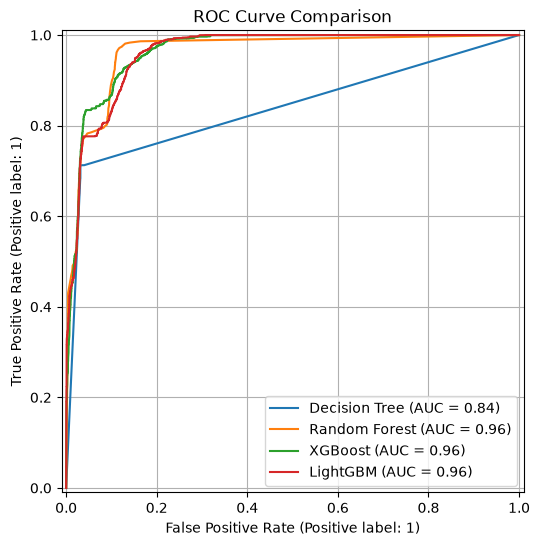

In [21]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


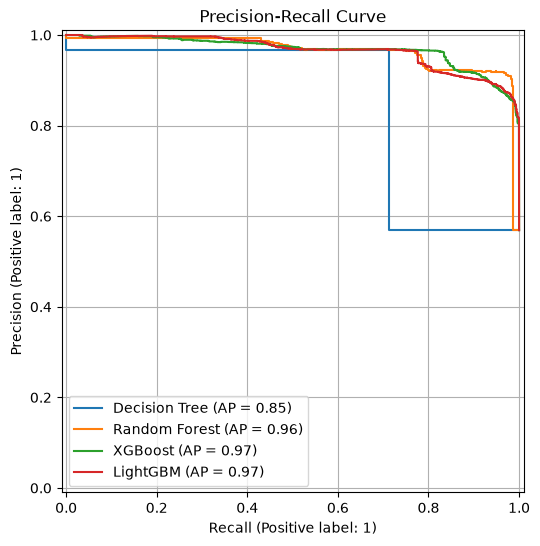

In [22]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8,6))

for name, model in models.items():

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

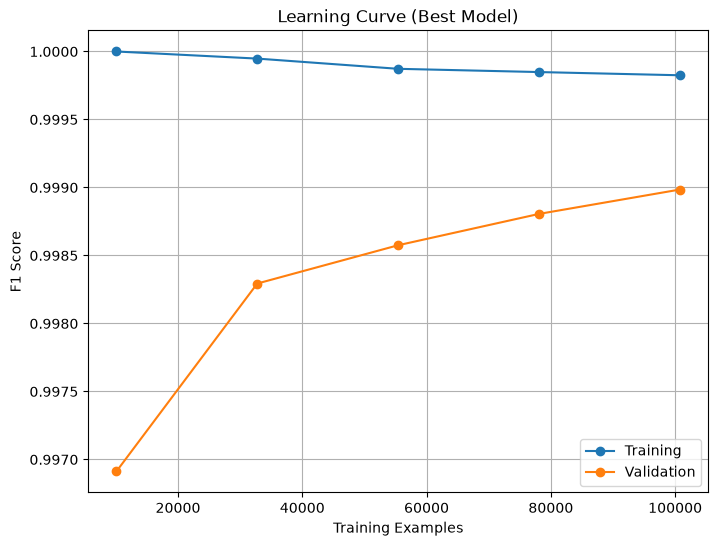

In [23]:
from sklearn.model_selection import learning_curve
import numpy as np

best_model = grid_xgb.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1,1.0,5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, marker='o', label="Training")
plt.plot(train_sizes, test_mean, marker='o', label="Validation")

plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.title("Learning Curve (Best Model)")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
print("Decision Tree")
print(grid_dt.best_params_)

print("\nRandom Forest")
print(grid_rf.best_params_)

print("\nXGBoost")
print(grid_xgb.best_params_)

print("\nLightGBM")
print(grid_lgbm.best_params_)

Decision Tree
{'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}

Random Forest
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}

XGBoost
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}

LightGBM
{'classifier__learning_rate': 0.1, 'classifier__n_estimators': 200, 'classifier__num_leaves': 31}


In [26]:
validation_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Cross Validation F1": [
        cv_results[0]["Mean F1"],
        cv_results[1]["Mean F1"],
        cv_results[2]["Mean F1"],
        cv_results[3]["Mean F1"]
    ]
})

validation_results = validation_results.round(4)

validation_results

,Model,Cross Validation F1
0,Decision Tree,0.9984
1,Random Forest,0.9989
2,XGBoost,0.9990
3,LightGBM,0.9993


In [27]:
validation_results.to_csv(
    "../reports/model_validation.csv",
    index=False
)

## Conclusion

- Hyperparameter tuning improved model robustness.
- Cross-validation confirmed that the selected models generalized consistently.
- ROC and Precision-Recall curves provided a more comprehensive evaluation than accuracy alone.
- The tuned models will be used for feature importance analysis and explainability in the next notebook.